In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Strategies.MultipleMarketsIntensity_class import MultiTradeIntensity as TI
from Math.ti_class import TI_class, VI_class, TR_class
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

tol=(1e-1)/2

In [10]:
class EMA:
    def __init__(self, span):
        self.span = span
        self.value = 0
        self.alpha = 2 / (span + 1)

    def push(self, value):
        self.value = self.alpha * value + (1 - self.alpha) * self.value

class TR_class:
    def __init__(self, tau, tau_ema, burn=10):
        self.tau = tau
        self.tau_ema = tau_ema
        self.reset()
        self.__burn = burn

    @property
    def param_keys(self):
        return ['tau', 'tau_ema']

    def update_params(self, params_dict):
        if 'tau' in params_dict.keys():
            self.tau = params_dict['tau']
        if 'tau_ema' in params_dict.keys():
            self.tau_ema = params_dict['tau_ema']

    @property
    def ewma_val(self):
        return self.ewma.value

    @property
    def is_burn(self):
        return self.tot_n < self.burn

    @property
    def min_tau(self):
        return self.tau // 3

    @property
    def old_value(self):
        return self.__old_value

    @property
    def bt(self):
        return self.__bt

    @property
    def burn(self):
        return self.__burn

    @property
    def tot_n(self):
        return self.__tot_n

    def reset(self):
        self.phiT = 0
        self.ewma = EMA(self.tau_ema)
        self.ewma_T = EMA(self.tau_ema)
        self.thres = 0
        self.index = 0
        self.__bt = 1
        self.__old_value = np.nan
        self.__n = 0
        self.__tot_n = 0
        self.init = False

    def soft_reset(self):
        self.phiT = 0
        self.ewma = EMA(self.tau_ema)
        self.ewma_T = EMA(self.tau_ema)
        self.thres = 0
        self.index += 1
        self.__bt = 1
        self.__n = 0
        self.__tot_n = 0
        self.init = False

    def initialize(self):
        self.ewma.value = .5
        self.ewma_T.value = self.tau
        self.init = False

    def push(self, value, volume=None):
        if self.tot_n < 1:
            self.init = True
        else:
            diff_value = value - self.old_value
            self.__bt = self.signed_tick_vals(diff_value)
            bt = max(self.__bt, 0)
            if self.init:
                self.initialize()
                self.thres = max(abs(self.ewma.value) * self.ewma_T.value, self.min_tau)
            if self.is_burn:
                self.phiT += bt
                self.__n += 1
            elif max(self.phiT, self.__n - self.phiT) < self.thres:
                self.phiT += bt
                self.__n += 1
            else:
                self.ewma.push(self.phiT / self.__n)
                self.ewma_T.push(self.__n)
                self.phiT = 0
                self.thres = max(abs(self.ewma.value) * self.ewma_T.value, self.min_tau)
                self.index += 1
                self.__n = 0
        self.__tot_n += 1
        self.__old_value = value
        return self.index

    def signed_tick_vals(self, diff_value):
        if diff_value > 0:
            return 1
        elif diff_value < 0:
            return -1
        else:
            return 0

    def tick_imbalance_single(self, trades):
        self.soft_reset()
        index_series = []
        for trade in trades:
            value = trade[0]
            if not value or np.isnan(value):
                index_series.append((trade[2], self.index))
            else:
                index_series.append((trade[2], self.push(value)))

        return index_series

    def tick_imbalance_indices(self, trades):
        self.reset()
        index_series = []
        current_date = None
        daily_trades = []

        for trade in trades:
            trade_date = trade[2].date()
            if current_date is None:
                current_date = trade_date

            if trade_date != current_date:
                # Process the previous day's trades
                index_series.extend(self.tick_imbalance_single(daily_trades))
                daily_trades = []
                current_date = trade_date

            daily_trades.append(trade)

        # Process the last day's trades
        if daily_trades:
            index_series.extend(self.tick_imbalance_single(daily_trades))

        return index_series

def get_nine_am_unix_today_cet():
    # Define the CET timezone
    cet = pytz.timezone('CET')

    # Get today's date in the CET timezone
    today = datetime.now(cet).date()

    # Combine today's date with the time 09:00 AM in CET
    nine_am_today = cet.localize(datetime.combine(today, time(9, 0)))

    # Convert to Unix timestamp (seconds since epoch)
    unix_timestamp = int(nine_am_today.timestamp())

    return unix_timestamp

def calculate_ema(current_price, previous_ema, span):
    alpha = 2 / (span + 1)
    return alpha * current_price + (1 - alpha) * previous_ema

def get_trades_for_contract(contract):
    params_dict={}
    params_dict['tenor_list'] = ['dec'] if contract=='euadec1' else [contract[-2]]
    params_dict['tn1_list'] = [int(contract[-1])]
    params_dict['mkt_list'] = ['eua'] * len(params_dict['tenor_list']) if contract=='euadec1' else [contract[0:-2]] * len(params_dict['tenor_list'])
    params_dict['tn2_list'] = []
    params_dict['prod'] = 'base'
    params_dict['venue_list'] = ['eex']*len(params_dict['mkt_list'])
    params_dict['start_date'] = date_3_business_days
    params_dict['end_date'] = date_1_business_days
    params_dict['ns'] = 2

    # Fetch trades and best orders for the curve
    assembler = TPDataAssembly(source='trayport', user='matej')
    # assembler.set_start_end_time(start=[10,0,0], end=[12,0,0])    
    trades_dict = assembler.get_data(params_dict, target_data='trades')
    #assembler.set_data_source('database')
    ba_dict = assembler.get_data(params_dict, target_data='best_orders')

    assert ba_dict.keys() == trades_dict.keys(), "Curve doesn't fit for both trades and best_orders"

    trades = pd.DataFrame()
    ba = pd.DataFrame()
    products = []
    for key in trades_dict.keys():
        ba_aux = ba_dict[key].copy()
        trade_aux = trades_dict[key].copy()
        trade_aux.columns = [a + '_' + key for a in trade_aux.columns]
        ba_aux.columns = [a + '_' + key for a in ba_aux.columns]
        if trades.empty:
            trades = trade_aux.copy()
        else:
            trades = pd.concat([trades, trade_aux])
        if ba.empty:
            ba = ba_aux.copy()
        else:
            ba = pd.concat([ba, ba_aux])
        products.append(key)
    trades.sort_index(inplace=True)
    ba.sort_index(inplace=True)
    ba.index.name='datetime'

    ti_inst = TI(trades, ba, products)

    ti_inst.prepare_data()


    data_raw = ti_inst.data

    df_lead = data_raw[data_raw['broker_id_'+contract]==1441][['price_'+contract, 'volume_'+contract,'bidbestprice_'+contract,
                      'askbestprice_'+contract, 'mid_'+contract, 'trade_side_'+contract]].copy()
    
    df_lead['contract']=contract

    # data = data_raw[['price_dem1', 'volume_dem1','bidbestprice_dem1',
    #                    'askbestprice_dem1', 'mid_dem1', 'trade_side_dem1']].copy()

    df_lead.columns = [a.split('_')[0] for a in df_lead.columns]
    df_lead.columns = ['trd_price', 'volume', 'bid_price', 'ask_price', 'mid_price', 'trd_side', 'contract']
    
    return df_lead

def fit_model(lead_contract, lag_contract):
    data_lead_trds = df[df['contract']==lead_contract]
    data_lag_trds = df[df['contract']==lag_contract]

    data_lead_trds['tag'] = 'lead'
    data_lag_trds['tag'] = 'lag'

    df_trds = pd.concat([data_lead_trds, data_lag_trds]).sort_index()

    df_trds['lead_price'] = df_trds[['trd_price', 'tag']].apply(lambda row: row['trd_price'] if row['tag'] == 'lead' else None, axis=1)
    df_trds['lead_volume'] = df_trds[['volume', 'tag']].apply(lambda row: row['volume'] if row['tag'] == 'lead' else None, axis=1)
    df_trds['lead_pv'] = df_trds[['trd_price', 'volume', 'tag']].apply(lambda row: row['trd_price'] * row['volume'] if row['tag'] == 'lead' else None, axis=1)

    df_trds['lag_price'] = df_trds[['trd_price', 'tag']].apply(lambda row: row['trd_price'] if row['tag'] == 'lag' else None, axis=1)
    df_trds['lag_volume'] = df_trds[['volume', 'tag']].apply(lambda row: row['volume'] if row['tag'] == 'lag' else None, axis=1)
    df_trds['lag_pv'] = df_trds[['trd_price', 'volume', 'tag']].apply(lambda row: row['trd_price'] * row['volume'] if row['tag'] == 'lag' else None, axis=1)



    agg_dict = {'index': 'first', 'datetime': 'first'}
    agg_dict.update({k: 'sum' for k in ['lead_volume', 'lead_pv', 'lag_volume', 'lag_pv']})

    df_trds['date'] = df_trds.index.date
    dates_list = sorted(list(set(df_trds['date'])))

    df_list = []
    df_list2 = []

    sort_order=[True, False, True]


    for current_day in dates_list:
        df_trds_1day = df_trds[df_trds['date'] == current_day].reset_index()
        df_trds_1day['execution_time'] = df_trds_1day['datetime'].astype('int64')  # Already in nanoseconds

        # Preparing tick data
        ti_cls = TR_class(tau=10, tau_ema=10)

        df_trds_1day = df_trds_1day.sort_values(by=['datetime', 'lag_volume', 'lag_price'], ascending=sort_order).reset_index()


        # Create the list of tuples
        lag_trades = [(row['lag_price'], row['volume'], row['execution_time']) for index, row in
                      df_trds_1day.iterrows()]


        idx_series = ti_cls.tick_imbalance_single(lag_trades)
        idx_series = pd.DataFrame(idx_series, columns=['index', 0])


        if 'level_0' in df_trds_1day.columns:
            del df_trds_1day['level_0']

        # Create returns
        df_trds_indexed_1day = pd.concat([df_trds_1day, idx_series[0]], axis=1).reset_index()
        lag_index = df_trds_indexed_1day[df_trds_indexed_1day['tag'] == 'lag'].index.min()
        lead_before_lag = df_trds_indexed_1day[(df_trds_indexed_1day['tag'] == 'lead') & (df_trds_indexed_1day.index < lag_index)]
        df_trds_indexed_1day.loc[lead_before_lag.index, 0] = 0

        df_trds_indexed_1day['tick_id'] = str(current_day) + '_' + df_trds_indexed_1day[0].fillna(0).apply(str)
        #df_trds_indexed_1day['datetime'] = df_trds_indexed_1day['timestamp']
        #df_trds_indexed_1day = df_trds_indexed_1day.set_index('datetime')
        df_trds_indexed_1day_grouped = df_trds_indexed_1day.groupby('tick_id').agg(
            agg_dict).reset_index().set_index('datetime')

        df_trds_indexed_1day_grouped['lead_price'] = df_trds_indexed_1day_grouped['lead_pv'] / \
                                                     df_trds_indexed_1day_grouped['lead_volume']
        df_trds_indexed_1day_grouped['lag_price'] = df_trds_indexed_1day_grouped['lag_pv'] / \
                                                    df_trds_indexed_1day_grouped['lag_volume']

        df_trds_indexed_1day_grouped['lead_log_ret'] = np.log(df_trds_indexed_1day_grouped['lead_price'].ffill() ).diff()
        df_trds_indexed_1day_grouped['lag_log_ret'] = np.log(df_trds_indexed_1day_grouped['lag_price'].ffill() ).diff()
        df_list.append(df_trds_indexed_1day_grouped)
        df_list2.append(df_trds_indexed_1day)

    df_trds_indexed = pd.concat(df_list).sort_index()
    df_trds = pd.concat([df_trds.sort_values(by=['datetime', 'lag_volume', 'lag_price'], ascending=sort_order).reset_index(drop=True), pd.concat(df_list2).sort_values(by=['datetime', 'lag_volume', 'lag_price'], ascending=sort_order).reset_index(drop=True)['tick_id']], axis=1)

    #Model fitting and scoring
    # Prepare to store predictions
    df_trds_indexed['lag_log_ret_pred'] = np.nan
    df_trds_indexed['coef1'] = np.nan
    df_trds_indexed['coef2'] = np.nan
    df_trds_indexed['date'] = df_trds_indexed.index.date
    dates_list = sorted(list(set(df_trds_indexed['date'])))    
    
    training_data = df_trds_indexed
    # Skip if not enough data


    # Independent variable (lead_log_ret) and dependent variable (lag_log_ret)
    X_train = training_data['lead_log_ret'].fillna(0)
    y_train = training_data['lag_log_ret'].fillna(0)

    # Add a constant to the independent variable
    X_train = sm.add_constant(X_train)

    # Fit the model using statsmodels
    model = sm.OLS(y_train, X_train).fit()
    
    return model.params[0], model.params[1], model.pvalues[0], model.pvalues[1], model.rsquared
    

# Data Loading

In [15]:
# Get today's date
today = np.datetime64('today', 'D')

# Calculate the date 3 business days from today
business_days = np.busday_offset(today, -100)

# Convert it to a datetime object if needed
date_3_business_days = np.datetime64(business_days).astype(datetime)
date_1_business_days = np.datetime64(np.busday_offset(today, -1)).astype(datetime)


print("Date 3 business days from today:", date_3_business_days)
print("Date 1 business day from today:", date_1_business_days)

Date 3 business days from today: 2025-02-14
Date 1 business day from today: 2025-07-03


In [16]:
contracts=['dem1', 'ttfm1', 'euadec1']

In [17]:
df=pd.concat([get_trades_for_contract(contract) for contract in contracts])

https://referencedata.trayport.com/instruments
Duration: 1.071s
https://analytics.trayport.com/api/trades?from=2025-02-14T07%3A00%3A00Z&until=2025-02-26T19%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=255&ContractType=SinglePeriod
Duration: 1.608s
https://referencedata.trayport.com/instruments
Duration: 0.900s
https://analytics.trayport.com/api/trades?from=2025-02-27T07%3A00%3A00Z&until=2025-03-27T19%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=256&ContractType=SinglePeriod
Duration: 2.572s
https://referencedata.trayport.com/instruments
Duration: 0.840s
https://analytics.trayport.com/api/trades?from=2025-03-28T07%3A00%3A00Z&until=2025-04-28T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=257&ContractType=SinglePeriod
Duration: 1.621s
https://referencedata.trayport.com/instruments
Duration: 0.788s
https://analytics.trayport.com/api/trades?from=2025-04-29T06%3A00%3A00Z&until=2025-05-28T18%3A00%3A00Z&instrumentId=1064171

https://referencedata.trayport.com/instruments
Duration: 1.017s
https://analytics.trayport.com/api/orders/book?from=2025-03-14T07%3A00%3A00Z&until=2025-03-14T19%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=256&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.333s
https://referencedata.trayport.com/instruments
Duration: 1.000s
https://analytics.trayport.com/api/orders/book?from=2025-03-17T07%3A00%3A00Z&until=2025-03-17T19%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=256&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.649s
https://referencedata.trayport.com/instruments
Duration: 0.885s
https://analytics.trayport.com/api/orders/book?from=2025-03-18T07%3A00%3A00Z&until=2025-03-18T19%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=256&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.075s
http

https://referencedata.trayport.com/instruments
Duration: 0.790s
https://analytics.trayport.com/api/orders/book?from=2025-04-18T06%3A00%3A00Z&until=2025-04-18T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=257&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 0.945s
https://referencedata.trayport.com/instruments
Duration: 1.258s
https://analytics.trayport.com/api/orders/book?from=2025-04-21T06%3A00%3A00Z&until=2025-04-21T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=257&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 0.940s
https://referencedata.trayport.com/instruments
Duration: 1.170s
https://analytics.trayport.com/api/orders/book?from=2025-04-22T06%3A00%3A00Z&until=2025-04-22T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=257&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 5.063s
http

https://referencedata.trayport.com/instruments
Duration: 0.992s
https://analytics.trayport.com/api/orders/book?from=2025-05-23T06%3A00%3A00Z&until=2025-05-23T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=258&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 6.424s
https://referencedata.trayport.com/instruments
Duration: 0.910s
https://analytics.trayport.com/api/orders/book?from=2025-05-26T06%3A00%3A00Z&until=2025-05-26T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=258&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.378s
https://referencedata.trayport.com/instruments
Duration: 0.859s
https://analytics.trayport.com/api/orders/book?from=2025-05-27T06%3A00%3A00Z&until=2025-05-27T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=258&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 5.854s
http

https://referencedata.trayport.com/instruments
Duration: 1.248s
https://analytics.trayport.com/api/orders/book?from=2025-06-27T06%3A00%3A00Z&until=2025-06-27T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=260&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 5.650s
https://referencedata.trayport.com/instruments
Duration: 1.060s
https://analytics.trayport.com/api/orders/book?from=2025-06-30T06%3A00%3A00Z&until=2025-06-30T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=260&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.682s
https://referencedata.trayport.com/instruments
Duration: 1.030s
https://analytics.trayport.com/api/orders/book?from=2025-07-01T06%3A00%3A00Z&until=2025-07-01T18%3A00%3A00Z&instrumentId=10641710&sequenceId=10000104&sequenceItemId=260&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.330s
http

...

https://referencedata.trayport.com/instruments
Duration: 0.730s
https://analytics.trayport.com/api/orders/book?from=2025-06-20T06%3A00%3A00Z&until=2025-06-20T18%3A00%3A00Z&instrumentId=10002806&sequenceId=10000305&sequenceItemId=259&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.275s
https://referencedata.trayport.com/instruments
Duration: 0.780s
https://analytics.trayport.com/api/orders/book?from=2025-06-23T06%3A00%3A00Z&until=2025-06-23T18%3A00%3A00Z&instrumentId=10002806&sequenceId=10000305&sequenceItemId=259&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.149s
https://referencedata.trayport.com/instruments
Duration: 1.640s
https://analytics.trayport.com/api/orders/book?from=2025-06-24T06%3A00%3A00Z&until=2025-06-24T18%3A00%3A00Z&instrumentId=10002806&sequenceId=10000305&sequenceItemId=259&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.769s
http

https://referencedata.trayport.com/instruments
Duration: 1.059s
https://analytics.trayport.com/api/orders/book?from=2025-03-03T07%3A00%3A00Z&until=2025-03-03T19%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.550s
https://referencedata.trayport.com/instruments
Duration: 1.100s
https://analytics.trayport.com/api/orders/book?from=2025-03-04T07%3A00%3A00Z&until=2025-03-04T19%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 2.992s
https://referencedata.trayport.com/instruments
Duration: 0.841s
https://analytics.trayport.com/api/orders/book?from=2025-03-05T07%3A00%3A00Z&until=2025-03-05T19%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.749s
http

https://referencedata.trayport.com/instruments
Duration: 1.061s
https://analytics.trayport.com/api/orders/book?from=2025-04-07T06%3A00%3A00Z&until=2025-04-07T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.201s
https://referencedata.trayport.com/instruments
Duration: 0.841s
https://analytics.trayport.com/api/orders/book?from=2025-04-08T06%3A00%3A00Z&until=2025-04-08T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.600s
https://referencedata.trayport.com/instruments
Duration: 1.047s
https://analytics.trayport.com/api/orders/book?from=2025-04-09T06%3A00%3A00Z&until=2025-04-09T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.878s
http

https://referencedata.trayport.com/instruments
Duration: 1.440s
https://analytics.trayport.com/api/orders/book?from=2025-05-12T06%3A00%3A00Z&until=2025-05-12T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 4.120s
https://referencedata.trayport.com/instruments
Duration: 1.440s
https://analytics.trayport.com/api/orders/book?from=2025-05-13T06%3A00%3A00Z&until=2025-05-13T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.350s
https://referencedata.trayport.com/instruments
Duration: 1.021s
https://analytics.trayport.com/api/orders/book?from=2025-05-14T06%3A00%3A00Z&until=2025-05-14T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.913s
http

https://referencedata.trayport.com/instruments
Duration: 0.909s
https://analytics.trayport.com/api/orders/book?from=2025-06-16T06%3A00%3A00Z&until=2025-06-16T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.960s
https://referencedata.trayport.com/instruments
Duration: 1.130s
https://analytics.trayport.com/api/orders/book?from=2025-06-17T06%3A00%3A00Z&until=2025-06-17T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 5.099s
https://referencedata.trayport.com/instruments
Duration: 0.831s
https://analytics.trayport.com/api/orders/book?from=2025-06-18T06%3A00%3A00Z&until=2025-06-18T18%3A00%3A00Z&instrumentId=10003008&sequenceId=10000400&sequenceItemId=790&ContractType=SinglePeriod&optionalFields=VenueCode&interval=1&intervalUnit=second
Duration: 3.893s
http

In [ ]:
df['contract'].value_counts()

In [7]:
df=df.reset_index()

In [8]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['timestamp'] = df['datetime']

In [9]:
df=df[df['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [10]:
df.set_index('datetime', inplace=True)

In [11]:
df.head()

,trd_price,volume,bid_price,ask_price,mid_price,trd_side,contract,timestamp
datetime,,,,,,,,
2025-04-24 09:00:00.351414680,70.53,1.0,70.6,70.61,70.605,-1.0,dem1,2025-04-24 09:00:00.351414680
2025-04-24 09:00:03.172896147,70.60,1.0,70.6,70.60,70.600,NaN,dem1,2025-04-24 09:00:03.172896147
2025-04-24 09:00:03.180626392,70.63,1.0,70.6,70.60,70.600,1.0,dem1,2025-04-24 09:00:03.180626392
2025-04-24 09:00:03.180676699,70.63,2.0,70.6,70.60,70.600,1.0,dem1,2025-04-24 09:00:03.180676699
2025-04-24 09:00:05.450591803,70.65,1.0,70.6,70.65,70.625,1.0,dem1,2025-04-24 09:00:05.450591803


# Model fitting

In [12]:
import matplotlib.pyplot as plt
from itertools import product

significance_level = 0.05


# Initialize matrices
coef1_matrix = pd.DataFrame(index=contracts, columns=contracts, dtype=float)
coef2_matrix = pd.DataFrame(index=contracts, columns=contracts, dtype=float)
r2_matrix     = pd.DataFrame(index=contracts, columns=contracts, dtype=float)

# Loop through pairs
for lead, lag in product(contracts, contracts):
    if lead != lag:
        try:
            coef1, coef2, pval1, pval2, r2 = fit_model(lead, lag)
            if pval2 < significance_level:
                coef1_matrix.loc[lead, lag] = coef1
                coef2_matrix.loc[lead, lag] = coef2
                r2_matrix.loc[lead, lag] = r2
            else:
                # Leave NaN to mark insignificant
                print(f"Insignificant model for {lead} vs {lag} (p1={pval1:.3f}, p2={pval2:.3f})")
        except Exception as e:
            print(f"Error with {lead} vs {lag}: {e}")
    else:
        coef1_matrix.loc[lead, lag] = np.nan
        coef2_matrix.loc[lead, lag] = np.nan
        r2_matrix.loc[lead, lag]     = np.nan


Insignificant model for dey1 vs frm1 (p1=0.711, p2=0.179)
Insignificant model for frm1 vs dem1 (p1=0.997, p2=0.076)
Insignificant model for euadec1 vs frm1 (p1=0.701, p2=0.746)
Insignificant model for euadec1 vs ttfm1 (p1=0.628, p2=0.136)


# Matrix visualisation

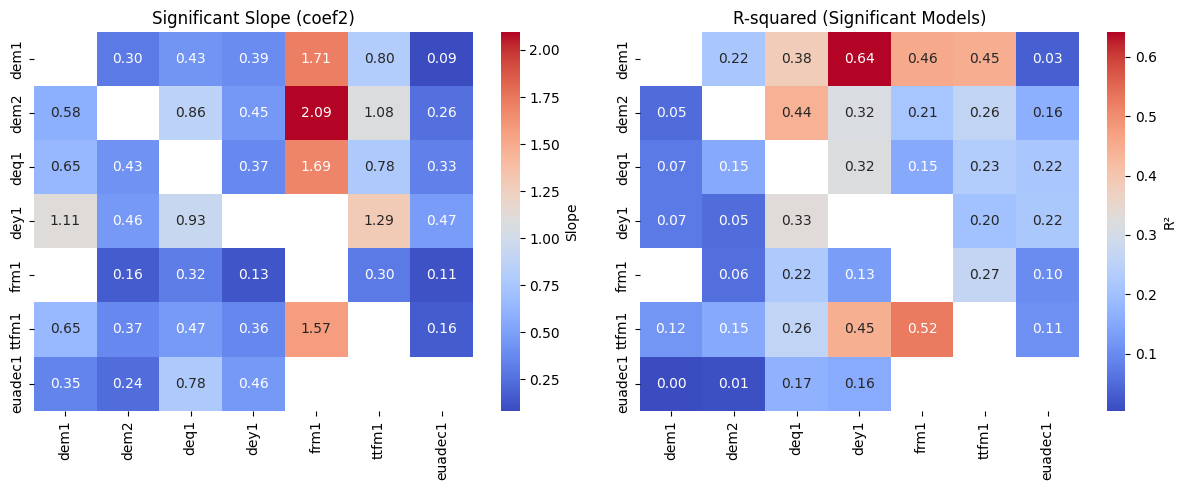

In [13]:
# Plotting
plt.figure(figsize=(18, 5))

# plt.subplot(1, 3, 1)
# sns.heatmap(coef1_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Intercept"})
# plt.title("Significant Intercept (coef1)")

plt.subplot(1, 3, 2)
sns.heatmap(coef2_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "Slope"})
plt.title("Significant Slope (coef2)")

plt.subplot(1, 3, 3)
sns.heatmap(r2_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label": "R²"})
plt.title("R-squared (Significant Models)")

plt.tight_layout()
plt.show()